# MVPA choice decoding: result review

This notebook reviews outputs from the Schaefer choice-decoding run (`choseAccept` with logistic regression).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dd_kable_analysis.config_loader import load_config

In [2]:
cfg = load_config()
analysis_tag = 'schaefer200_choseAccept_logreg'
analysis_dir = Path(cfg.output_root) / f'mvpa_{analysis_tag}'
analysis_dir

PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_schaefer200_choseAccept_logreg')

In [3]:
# Optional override: set to a specific subject id like 'dmp0356'
TEST_SUB_ID = None

sub_dirs = sorted([p for p in analysis_dir.glob('sub-*') if p.is_dir()])

if TEST_SUB_ID is not None:
    selected_sub_dir = analysis_dir / f'sub-{TEST_SUB_ID}'
else:
    # choose most recently modified subject folder
    selected_sub_dir = (
        max(sub_dirs, key=lambda p: p.stat().st_mtime) if sub_dirs else None
    )

selected_sub_dir

PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_schaefer200_choseAccept_logreg/sub-dmp1271')

In [4]:
if selected_sub_dir is None or not selected_sub_dir.exists():
    raise FileNotFoundError(f'No subject output folders found in {analysis_dir}')

roi_summary_path = selected_sub_dir / 'roi_summary.csv'
trialwise_path = selected_sub_dir / 'trialwise_preds.csv'
meta_path = selected_sub_dir / 'meta.json'
success_path = selected_sub_dir / '_SUCCESS'

for p in [roi_summary_path, trialwise_path, meta_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing expected output file: {p}')

print('Selected subject folder:', selected_sub_dir)
print('Has _SUCCESS:', success_path.exists())

Selected subject folder: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_schaefer200_choseAccept_logreg/sub-dmp1271
Has _SUCCESS: True


In [5]:
with open(meta_path, 'r') as f:
    meta = json.load(f)

roi_summary_df = pd.read_csv(roi_summary_path)
trialwise_df = pd.read_csv(trialwise_path)

meta

{'sub_id': 'dmp1271',
 'atlas': 'schaefer200',
 'atlas_source': 'nilearn.fetch_atlas_schaefer_2018(n_rois=200, networks=7, res=2mm)',
 'atlas_img': '/home/users/jmumford/nilearn_data/schaefer_2018/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii.gz',
 'roi_labels': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
 

In [6]:
print('roi_summary shape:', roi_summary_df.shape)
print('trialwise shape:', trialwise_df.shape)

display(roi_summary_df.head())
display(trialwise_df.head())

roi_summary shape: (200, 13)
trialwise shape: (23200, 10)


,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,sensitivity,specificity,balanced_accuracy,accuracy,roc_auc,log_loss,mean_C
0,dmp1271,1,116,4,6242,5505,0.238095,0.905405,0.571750,0.663793,0.625161,0.644224,0.000829
1,dmp1271,2,116,4,4830,4361,0.404762,0.824324,0.614543,0.672414,0.698198,0.602633,0.001000
2,dmp1271,3,116,4,3349,2991,0.309524,0.851351,0.580438,0.655172,0.652188,0.625673,0.002081
3,dmp1271,4,116,4,2483,2284,0.357143,0.864865,0.611004,0.681034,0.632883,0.678448,0.003791
4,dmp1271,5,116,4,1984,1854,0.452381,0.810811,0.631596,0.681034,0.713642,0.616864,0.003162


,sub_id,roi_label,run,trial_type,Delay,amount,choseAccept,y,p_hat,y_pred
0,dmp1271,1,1,trial00,89,64,0,0,0.267830,0
1,dmp1271,1,1,trial01,159,65,0,0,0.347742,0
2,dmp1271,1,1,trial02,58,66,1,1,0.177826,0
3,dmp1271,1,1,trial03,37,63,1,1,0.177313,0
4,dmp1271,1,1,trial04,92,79,1,1,0.262442,0


In [7]:
np.mean(trialwise_df['choseAccept'])

np.float64(0.3620689655172414)

In [8]:
# test_roi = roi_summary_df.iloc[0]['roi_label']
test_roi = 9
test_trials = trialwise_df[trialwise_df['roi_label'] == test_roi]

# Group by run and check predictions
print('Predictions by run (one ROI):')
print(test_trials.groupby('run')['p_hat'].agg(['mean', 'std', 'count']))

Predictions by run (one ROI):
         mean       std  count
run                           
1    0.256022  0.178905     29
2    0.456715  0.206728     29
3    0.526634  0.287739     29
4    0.312976  0.241091     29


In [9]:
test_roi

9

In [10]:
roi_summary_df[roi_summary_df['roi_label'] == 9]

,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,sensitivity,specificity,balanced_accuracy,accuracy,roc_auc,log_loss,mean_C
8,dmp1271,9,116,4,1550,1471,0.547619,0.864865,0.706242,0.75,0.774131,0.535125,0.008291


In [11]:
test_trials = trialwise_df[trialwise_df['roi_label'] == 9]

print('Predictions by actual choice (y):')
by_choice = test_trials.groupby('y')['p_hat'].agg(
    ['mean', 'std', 'min', 'max', 'count']
)
print(by_choice)

# Calculate separation
mean_y0 = by_choice.loc[0, 'mean']
mean_y1 = by_choice.loc[1, 'mean']
separation = mean_y1 - mean_y0

print(f'\nSeparation (mean_y1 - mean_y0): {separation:.4f}')
print(f"Effect size (Cohen's d): {separation / test_trials['p_hat'].std():.2f}")

Predictions by actual choice (y):
       mean       std       min       max  count
y                                               
0  0.297716  0.203629  0.021999  0.895732     74
1  0.547311  0.256862  0.109721  0.925687     42

Separation (mean_y1 - mean_y0): 0.2496
Effect size (Cohen's d): 0.98


## ROI-level sanity checks

In [12]:
expected_roi_cols = [
    'sub_id',
    'roi_label',
    'n_trials',
    'n_runs',
    'n_vox_preQC',
    'n_vox_postQC',
    'sensitivity',
    'specificity',
    'balanced_accuracy',
    'accuracy',
    'roc_auc',
    'log_loss',
    'mean_C',
]

missing_cols = [c for c in expected_roi_cols if c not in roi_summary_df.columns]
print('Missing expected ROI columns:', missing_cols)

roi_summary_df[['balanced_accuracy', 'roc_auc', 'log_loss', 'mean_C']].describe()

Missing expected ROI columns: []


,balanced_accuracy,roc_auc,log_loss,mean_C
count,200.000000,200.000000,200.000000,200.000000
mean,0.561398,0.616947,0.652902,0.007086
std,0.053505,0.065790,0.035528,0.004698
min,0.425997,0.448520,0.535125,0.000829
25%,0.526384,0.570946,0.632874,0.004331
50%,0.556789,0.612452,0.656488,0.006041
75%,0.591136,0.658060,0.675791,0.008291
max,0.731982,0.790541,0.764671,0.037906


In [13]:
print('Top 10 ROIs by balanced_accuracy')
display(
    roi_summary_df.sort_values('balanced_accuracy', ascending=False)
    .loc[
        :,
        [
            'roi_label',
            'balanced_accuracy',
            'accuracy',
            'roc_auc',
            'log_loss',
            'n_vox_postQC',
        ],
    ]
    .head(10)
)

print('Top 10 ROIs by roc_auc')
display(
    roi_summary_df.sort_values('roc_auc', ascending=False, na_position='last')
    .loc[
        :,
        [
            'roi_label',
            'roc_auc',
            'balanced_accuracy',
            'accuracy',
            'log_loss',
            'n_vox_postQC',
        ],
    ]
    .head(10)
)

Top 10 ROIs by balanced_accuracy


,roi_label,balanced_accuracy,accuracy,roc_auc,log_loss,n_vox_postQC
110,111,0.731982,0.750000,0.790541,0.586917,705
8,9,0.706242,0.750000,0.774131,0.535125,1471
109,110,0.701416,0.724138,0.744852,0.581321,603
112,113,0.680824,0.724138,0.736486,0.621585,742
14,15,0.677606,0.706897,0.706242,0.599120,876
113,114,0.674067,0.715517,0.738095,0.572615,619
107,108,0.670849,0.698276,0.707851,0.619995,636
103,104,0.667310,0.706897,0.693050,0.650500,653
10,11,0.664093,0.689655,0.719112,0.602877,1291
49,50,0.663771,0.715517,0.772201,0.544007,615


Top 10 ROIs by roc_auc


,roi_label,roc_auc,balanced_accuracy,accuracy,log_loss,n_vox_postQC
110,111,0.790541,0.731982,0.750000,0.586917,705
11,12,0.788932,0.645431,0.672414,0.564080,1027
8,9,0.774131,0.706242,0.750000,0.535125,1471
49,50,0.772201,0.663771,0.715517,0.544007,615
105,106,0.756757,0.606178,0.655172,0.552918,710
13,14,0.750965,0.660553,0.698276,0.583793,1078
12,13,0.748069,0.636744,0.681034,0.590814,1243
109,110,0.744852,0.701416,0.724138,0.581321,603
113,114,0.738095,0.674067,0.715517,0.572615,619
101,102,0.737773,0.650257,0.698276,0.603984,660


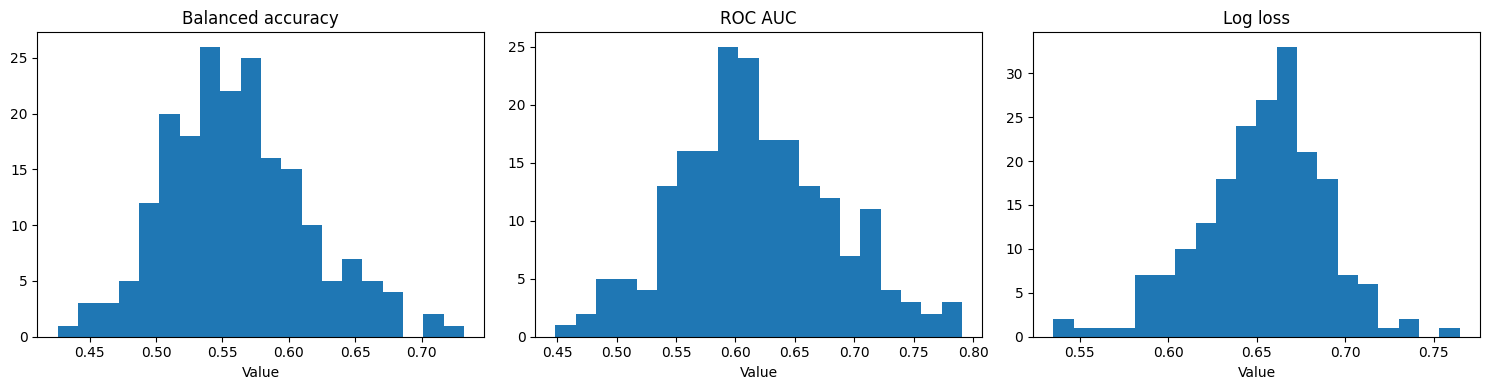

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(roi_summary_df['balanced_accuracy'].dropna(), bins=20)
axes[0].set_title('Balanced accuracy')
axes[0].set_xlabel('Value')

axes[1].hist(roi_summary_df['roc_auc'].dropna(), bins=20)
axes[1].set_title('ROC AUC')
axes[1].set_xlabel('Value')

axes[2].hist(roi_summary_df['log_loss'].dropna(), bins=20)
axes[2].set_title('Log loss')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

[fetch_atlas_schaefer_2018] Dataset found in /home/users/jmumford/nilearn_data/schaefer_2018
Saved voxelwise ROC AUC map to: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_schaefer200_choseAccept_logreg/sub-dmp1271/roc_auc_schaefer200_voxelmap.nii.gz
Mapped ROIs: 200 of 200


/tmp/ipykernel_12623/888737945.py:43: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  display = plotting.plot_stat_map(


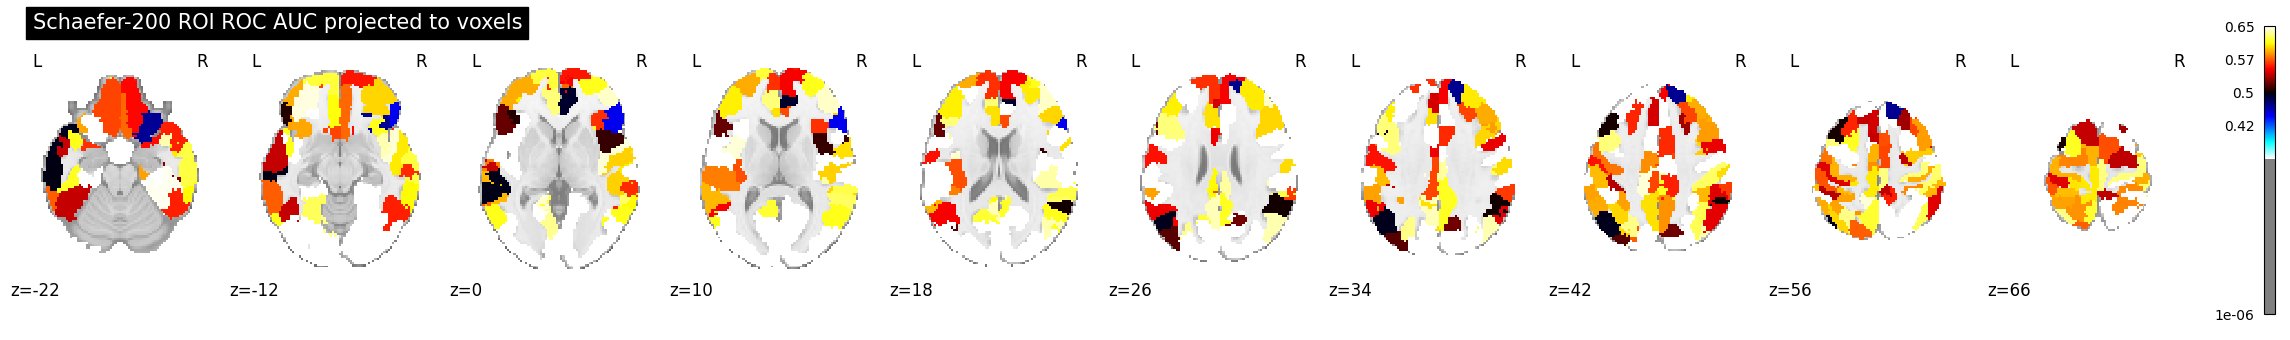

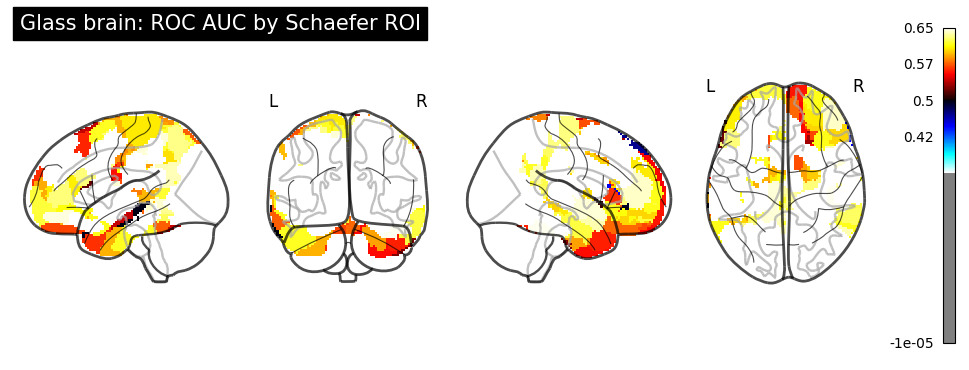

In [15]:
# Brain map: project ROI-level ROC AUC back into Schaefer-200 voxel space
import nibabel as nib
from nilearn import datasets, plotting

atlas_name = str(meta.get('atlas', '')).lower()
atlas_img_path = Path(str(meta.get('atlas_img', '')))

if atlas_name == 'schaefer200':
    sch = datasets.fetch_atlas_schaefer_2018(
        n_rois=200, yeo_networks=7, resolution_mm=2
    )
    atlas_img_ref = sch.maps
elif atlas_img_path.exists():
    atlas_img_ref = str(atlas_img_path)
else:
    raise FileNotFoundError(
        f'Could not resolve atlas image from meta. atlas={atlas_name}, atlas_img={atlas_img_path}'
    )

atlas_nii = nib.load(str(atlas_img_ref))
atlas_data = atlas_nii.get_fdata().astype(int)

roc_by_roi = (
    roi_summary_df[['roi_label', 'roc_auc']]
    .dropna(subset=['roi_label', 'roc_auc'])
    .assign(roi_label=lambda d: d['roi_label'].astype(int))
    .drop_duplicates(subset=['roi_label'])
    .set_index('roi_label')['roc_auc']
    .to_dict()
)

roc_map_data = np.full(atlas_data.shape, np.nan, dtype=np.float32)
for roi_label, roc_auc in roc_by_roi.items():
    roc_map_data[atlas_data == int(roi_label)] = float(roc_auc)

roc_auc_img = nib.Nifti1Image(roc_map_data, atlas_nii.affine, atlas_nii.header)
roc_auc_map_path = selected_sub_dir / 'roc_auc_schaefer200_voxelmap.nii.gz'
nib.save(roc_auc_img, str(roc_auc_map_path))

print('Saved voxelwise ROC AUC map to:', roc_auc_map_path)
print('Mapped ROIs:', len(roc_by_roi), 'of', int(np.nanmax(atlas_data)))

display = plotting.plot_stat_map(
    roc_auc_img,
    display_mode='z',
    cut_coords=10,
    cmap='cold_hot',
    vmin=0.35,
    vmax=0.65,
    colorbar=True,
    title='Schaefer-200 ROI ROC AUC projected to voxels',
)
plotting.show()

display = plotting.plot_glass_brain(
    roc_auc_img,
    display_mode='lyrz',
    cmap='cold_hot',
    vmin=0.35,
    vmax=0.65,
    colorbar=True,
    title='Glass brain: ROC AUC by Schaefer ROI',
)
plotting.show()

## Trialwise sanity checks

In [16]:
expected_trial_cols = ['sub_id', 'roi_label', 'run', 'y', 'p_hat', 'y_pred']
missing_trial_cols = [c for c in expected_trial_cols if c not in trialwise_df.columns]
print('Missing expected trialwise columns:', missing_trial_cols)

print('Unique y values:', sorted(trialwise_df['y'].dropna().unique().tolist()))
print(
    'Unique y_pred values:', sorted(trialwise_df['y_pred'].dropna().unique().tolist())
)

Missing expected trialwise columns: []
Unique y values: [0, 1]
Unique y_pred values: [0, 1]


In [17]:
# Aggregate confusion matrix across all ROI-trial rows (quick sanity check)
y = trialwise_df['y'].astype(int).to_numpy()
yp = trialwise_df['y_pred'].astype(int).to_numpy()

tp = int(((y == 1) & (yp == 1)).sum())
tn = int(((y == 0) & (yp == 0)).sum())
fp = int(((y == 0) & (yp == 1)).sum())
fn = int(((y == 1) & (yp == 0)).sum())

sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
bal_acc = np.nanmean([sens, spec])
acc = (tp + tn) / len(y)

print({'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn})
print(
    {
        'sensitivity': sens,
        'specificity': spec,
        'balanced_accuracy': bal_acc,
        'accuracy': acc,
    }
)

{'tp': 2678, 'tn': 11899, 'fp': 2901, 'fn': 5722}
{'sensitivity': 0.3188095238095238, 'specificity': 0.8039864864864865, 'balanced_accuracy': np.float64(0.5613980051480052), 'accuracy': 0.6283189655172414}


In [18]:
# percent of trials that were accept
# Sensitivity is accuracy on y=1 trials, specificity is accuracy on y=0 trials
# Checking whether ther are more y=0 trials because the specificity is so high (compared to sensitivity)
print('Percent of trials that were accept (y=1):', (y == 1).mean())

Percent of trials that were accept (y=1): 0.3620689655172414


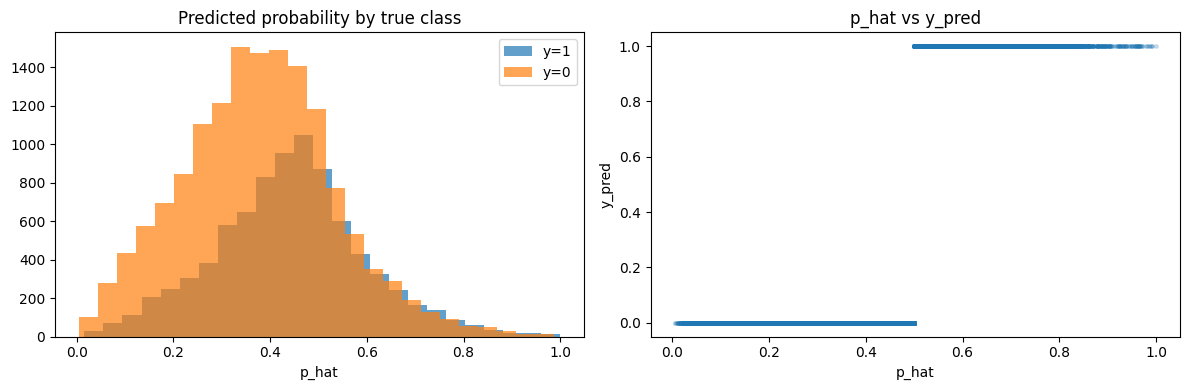

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    trialwise_df.loc[trialwise_df['y'] == 1, 'p_hat'].dropna(),
    bins=25,
    alpha=0.7,
    label='y=1',
)
axes[0].hist(
    trialwise_df.loc[trialwise_df['y'] == 0, 'p_hat'].dropna(),
    bins=25,
    alpha=0.7,
    label='y=0',
)
axes[0].set_title('Predicted probability by true class')
axes[0].set_xlabel('p_hat')
axes[0].legend()

axes[1].scatter(trialwise_df['p_hat'], trialwise_df['y_pred'], s=6, alpha=0.2)
axes[1].set_title('p_hat vs y_pred')
axes[1].set_xlabel('p_hat')
axes[1].set_ylabel('y_pred')

plt.tight_layout()
plt.show()

## Compare activation estimates to prediction results

Loaded subject files: 111
Unique subjects: 111
Rows: 22200
Unique ROIs: 200


,sub_id,roi_label,roc_auc,balanced_accuracy
0,dmp0011,1,0.545788,0.536630
1,dmp0011,2,0.562771,0.581419
2,dmp0011,3,0.588412,0.536297
3,dmp0011,4,0.716950,0.658175
4,dmp0011,5,0.685315,0.652181


Per-ROI subject count summary:


count    200.0
mean     111.0
std        0.0
min      111.0
25%      111.0
50%      111.0
75%      111.0
max      111.0
Name: sub_id, dtype: float64

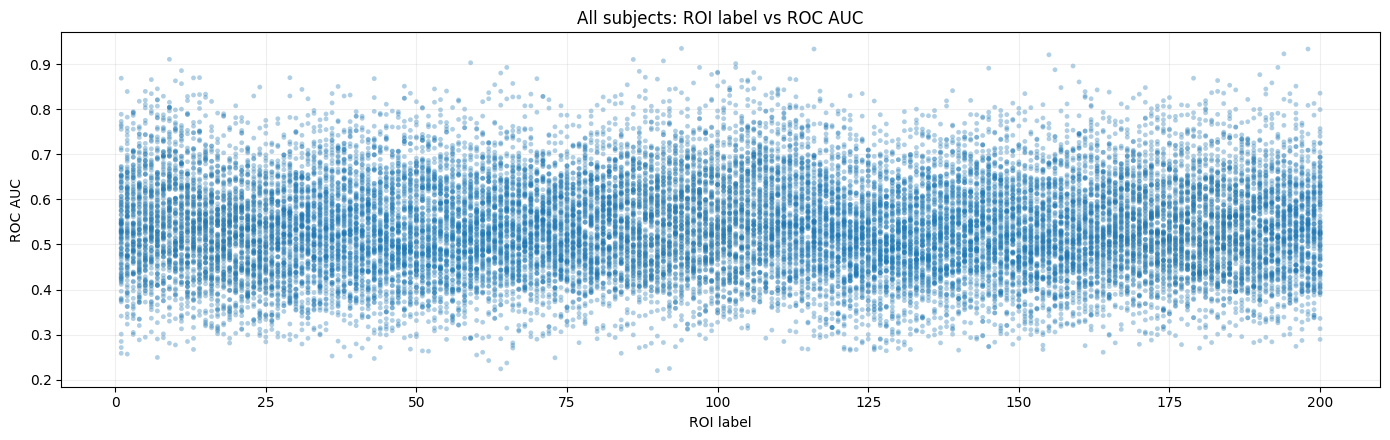

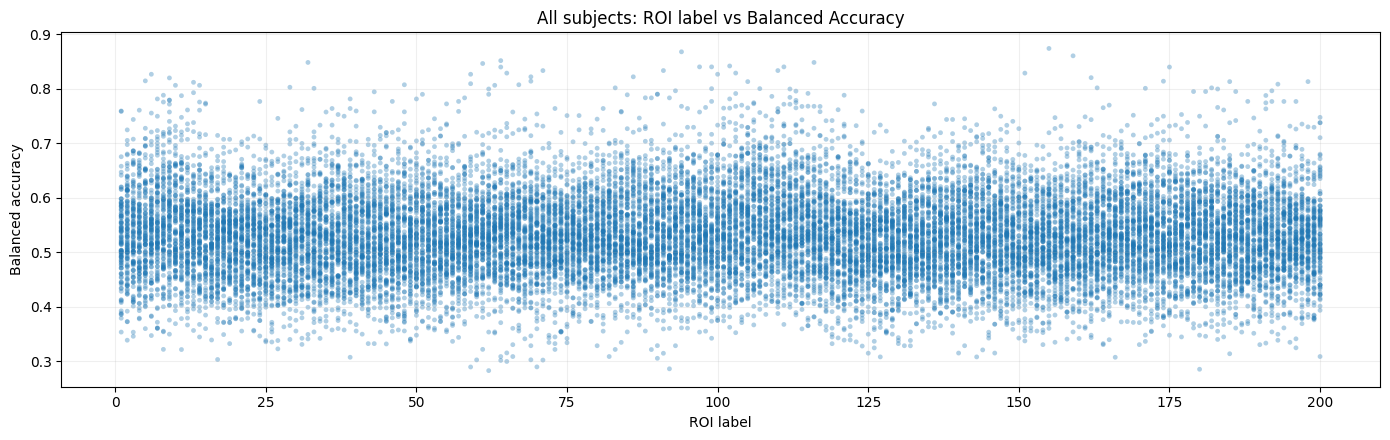

In [20]:
# Import all subject classifier results
from IPython.display import display as ipy_display

all_roi_paths = sorted(analysis_dir.glob('sub-*/roi_summary.csv'))

if not all_roi_paths:
    raise FileNotFoundError(f'No roi_summary.csv files found under {analysis_dir}')

all_roi_parts = []
for p in all_roi_paths:
    df = pd.read_csv(p)

    # ensure subject id exists and is clean
    if 'sub_id' not in df.columns:
        df['sub_id'] = p.parent.name.replace('sub-', '')
    df['sub_id'] = df['sub_id'].astype(str).str.replace('^sub-', '', regex=True)

    # keep only columns needed for this step
    keep_cols = ['sub_id', 'roi_label', 'roc_auc', 'balanced_accuracy']
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns {missing} in {p}')

    all_roi_parts.append(df[keep_cols].copy())

all_roi_df = pd.concat(all_roi_parts, ignore_index=True)
all_roi_df['roi_label'] = all_roi_df['roi_label'].astype(int)

print('Loaded subject files:', len(all_roi_paths))
print('Unique subjects:', all_roi_df['sub_id'].nunique())
print('Rows:', len(all_roi_df))
print('Unique ROIs:', all_roi_df['roi_label'].nunique())

ipy_display(all_roi_df.head())

grouped = all_roi_df.groupby('roi_label')
print('Per-ROI subject count summary:')
ipy_display(grouped['sub_id'].nunique().describe())

# Figure 1: ROI label vs ROC AUC (all subject-ROI rows)
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.scatter(
    all_roi_df['roi_label'],
    all_roi_df['roc_auc'],
    s=12,
    alpha=0.35,
    edgecolors='none',
)
ax.set_xlabel('ROI label')
ax.set_ylabel('ROC AUC')
ax.set_title('All subjects: ROI label vs ROC AUC')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Figure 2: ROI label vs Balanced Accuracy (all subject-ROI rows)
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.scatter(
    all_roi_df['roi_label'],
    all_roi_df['balanced_accuracy'],
    s=12,
    alpha=0.35,
    edgecolors='none',
)
ax.set_xlabel('ROI label')
ax.set_ylabel('Balanced accuracy')
ax.set_title('All subjects: ROI label vs Balanced Accuracy')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

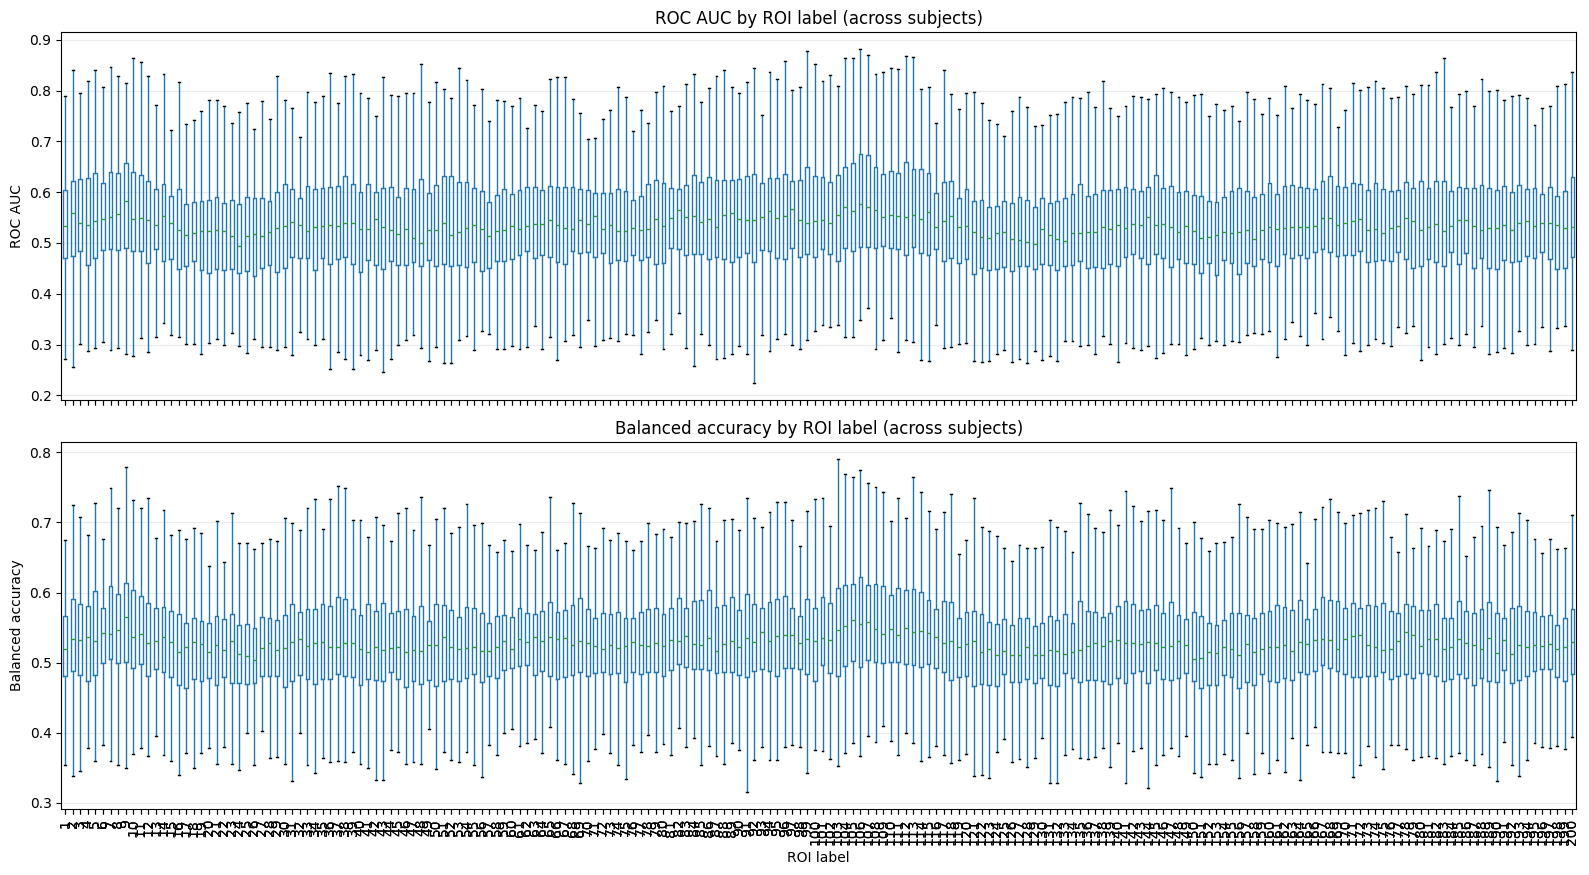

In [21]:
# boxplots
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Top: ROC AUC by ROI label
all_roi_df.boxplot(
    column='roc_auc',
    by='roi_label',
    ax=axes[0],
    grid=False,
    showfliers=False,
    rot=90,
)
axes[0].set_title('ROC AUC by ROI label (across subjects)')
axes[0].set_ylabel('ROC AUC')
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.25)

# Bottom: Balanced accuracy by ROI label
all_roi_df.boxplot(
    column='balanced_accuracy',
    by='roi_label',
    ax=axes[1],
    grid=False,
    showfliers=False,
    rot=90,
)
axes[1].set_title('Balanced accuracy by ROI label (across subjects)')
axes[1].set_ylabel('Balanced accuracy')
axes[1].set_xlabel('ROI label')
axes[1].grid(axis='y', alpha=0.25)

# pandas boxplot adds an automatic suptitle; remove it for cleaner display
plt.suptitle('')
plt.tight_layout()
plt.show()

In [22]:
output_root = Path(cfg.output_root)
traditional_dir = output_root / 'traditional_model' / 'first_level'


def collect_maps(base_dir: Path):
    ll_minus_ss_pattern = '*contrast-ll_minus_ss_output-effectsize.nii.gz'
    return sorted(base_dir.glob(f'sub-*/contrast_estimates/{ll_minus_ss_pattern}'))


def index_maps(paths):
    index = {}
    regex = re.compile(
        r'sub-(?P<sub>[^_]+)_ses-(?P<ses>[^_]+)_task-(?P<task>[^_]+)_'
        r'run-(?P<run>[^_]+)_ll_minus_ss_output-effectsize.nii.gz'
    )
    for p in paths:
        match = regex.search(p.name)
        if not match:
            continue
        key = (match.group('sub'), match.group('run'))
        index[key] = p
    return index

In [23]:
trad_maps = collect_maps(traditional_dir)
print(f'Num trad_maps = {len(trad_maps)}')

Num trad_maps = 439


In [24]:
from nilearn.glm.second_level import SecondLevelModel

design_matrix = pd.DataFrame({'intercept': np.ones(len(trad_maps))})


trad_slm = SecondLevelModel(smoothing_fwhm=cfg.smoothing_fwhm)
trad_slm = trad_slm.fit(trad_maps, design_matrix=design_matrix)
trad_zmap = trad_slm.compute_contrast(
    second_level_contrast='intercept', output_type='z_score'
)

## ROI-average z-stats vs classifier metrics

In [25]:
import nibabel as nib
import numpy as np
from nilearn.image import resample_to_img

# Load z-stat map data
zmap_data = trad_zmap.get_fdata()

# The Schaefer atlas (from nilearn) is in MNI152NLin6Asym space (91x109x91 at 2mm),
# while the z-map is in MNI152NLin2009cAsym space (97x115x97 at 2mm) — same voxel
# size but different bounding boxes. Resample the atlas into the z-map's grid using
# nearest-neighbour interpolation to preserve integer parcel labels.
atlas_nii = nib.load(str(atlas_img_ref))
atlas_resampled = resample_to_img(atlas_nii, trad_zmap, interpolation='nearest')
atlas_data = atlas_resampled.get_fdata().astype(int)

# Compute mean z-stat within each parcel
roi_labels_sorted = sorted(r for r in np.unique(atlas_data) if r != 0)
roi_zstat = {}
for label in roi_labels_sorted:
    mask = atlas_data == label
    roi_zstat[int(label)] = float(np.nanmean(zmap_data[mask]))

zstat_df = pd.DataFrame(list(roi_zstat.items()), columns=['roi_label', 'mean_zstat'])
print(f'ROIs with z-stat averages: {len(zstat_df)}')
zstat_df.head()

/tmp/ipykernel_12623/2178708568.py:13: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_resampled = resample_to_img(atlas_nii, trad_zmap, interpolation='nearest')
/tmp/ipykernel_12623/2178708568.py:13: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_resampled = resample_to_img(atlas_nii, trad_zmap, interpolation='nearest')


ROIs with z-stat averages: 200


,roi_label,mean_zstat
0,1,-1.481772
1,2,-0.960302
2,3,0.693933
3,4,0.368019
4,5,-2.402989


In [26]:
# Average classifier metrics across subjects per ROI, then merge with z-stats
# Uses all subjects loaded into `all_roi_df`.
clf_group = (
    all_roi_df.groupby('roi_label')[['roc_auc', 'balanced_accuracy']]
    .mean()
    .reset_index()
)

compare_df = zstat_df.merge(clf_group, on='roi_label', how='inner')
print(f'ROIs in merged table: {len(compare_df)}')
compare_df.describe()

ROIs in merged table: 200


,roi_label,mean_zstat,roc_auc,balanced_accuracy
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.442337,0.539955,0.530789
std,57.879185,1.960193,0.014169,0.010518
min,1.000000,-5.866259,0.502857,0.506653
25%,50.750000,-1.109200,0.531191,0.524159
50%,100.500000,0.225078,0.540391,0.529330
75%,150.250000,2.016302,0.547301,0.536220
max,200.000000,5.415623,0.582436,0.564991


/tmp/ipykernel_12623/1172740656.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


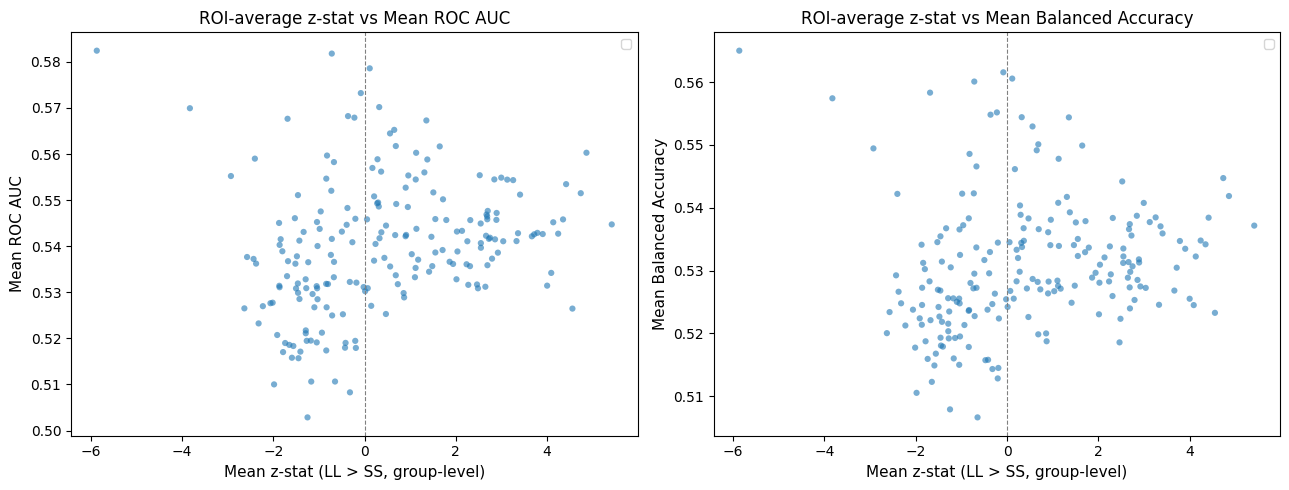

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], 'roc_auc', 'Mean ROC AUC'),
    (axes[1], 'balanced_accuracy', 'Mean Balanced Accuracy'),
]:
    ax.scatter(
        compare_df['mean_zstat'],
        compare_df[metric],
        s=20,
        alpha=0.6,
        edgecolors='none',
    )

    # # add a simple regression line
    # m, b = np.polyfit(compare_df['mean_zstat'], compare_df[metric], 1)
    # x_line = np.linspace(
    #     compare_df['mean_zstat'].min(), compare_df['mean_zstat'].max(), 100
    # )
    # ax.plot(
    #     x_line, m * x_line + b, color='firebrick', linewidth=1.5, label=f'slope={m:.3f}'
    # )

    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean z-stat (LL > SS, group-level)', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'ROI-average z-stat vs {label}', fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

ROI with smallest mean z-stat: 9
Mean z-stat: -5.8663
N subjects contributing: 111


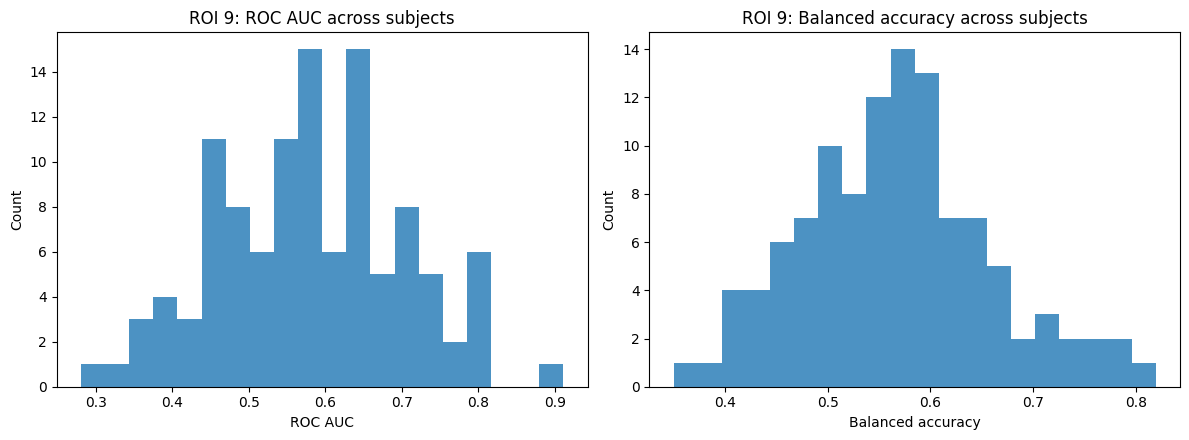

In [28]:
# ROI with smallest mean z-stat: histogram of classifier metrics across subjects
if 'compare_df' not in globals() or compare_df.empty:
    raise ValueError(
        'compare_df is missing or empty. Run the ROI-average z-stat merge cell first.'
    )

if 'all_roi_df' not in globals() or all_roi_df.empty:
    raise ValueError(
        'all_roi_df is missing or empty. Run the all-subject classifier import cell first.'
    )

min_row = compare_df.loc[compare_df['mean_zstat'].idxmin()]
min_roi = int(min_row['roi_label'])
min_z = float(min_row['mean_zstat'])

roi_sub_df = all_roi_df.loc[all_roi_df['roi_label'] == min_roi].copy()

print(f'ROI with smallest mean z-stat: {min_roi}')
print(f'Mean z-stat: {min_z:.4f}')
print(f'N subjects contributing: {roi_sub_df["sub_id"].nunique()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(roi_sub_df['roc_auc'].dropna(), bins=20, alpha=0.8)
axes[0].set_title(f'ROI {min_roi}: ROC AUC across subjects')
axes[0].set_xlabel('ROC AUC')
axes[0].set_ylabel('Count')

axes[1].hist(roi_sub_df['balanced_accuracy'].dropna(), bins=20, alpha=0.8)
axes[1].set_title(f'ROI {min_roi}: Balanced accuracy across subjects')
axes[1].set_xlabel('Balanced accuracy')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()